In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../../BIG_DATA/data/Patrimoine_Arbore_Nettoye.csv")

def preparation_donnees(df):
    colonnes_utiles = ['haut_tot', 'fk_stadedev', 'age_estim', 'tronc_diam', 'lat', 'long']

    # Suppresion "Non renseigné"
    df_prepare = df[df['fk_stadedev'] != 'Non renseigné'].copy()
    df_prepare = df_prepare[colonnes_utiles].dropna()

    mapping = {
        "Jeune": 1,
        "Adulte": 2,
        "Vieux/Sénescent": 3
    }
    df_prepare['fk_stadedev'] = df_prepare['fk_stadedev'].map(mapping)

    # Conversion hauteur cm -> m
    df_prepare['haut_tot'] = df_prepare['haut_tot'] / 100

    # Scaling
    scaler = StandardScaler()
    features = ['haut_tot', 'fk_stadedev', 'age_estim', 'tronc_diam']
    X_scaled = scaler.fit_transform(df_prepare[features])

    return df_prepare, X_scaled, scaler

df_prepare, X_scaled, scaler = preparation_donnees(df)

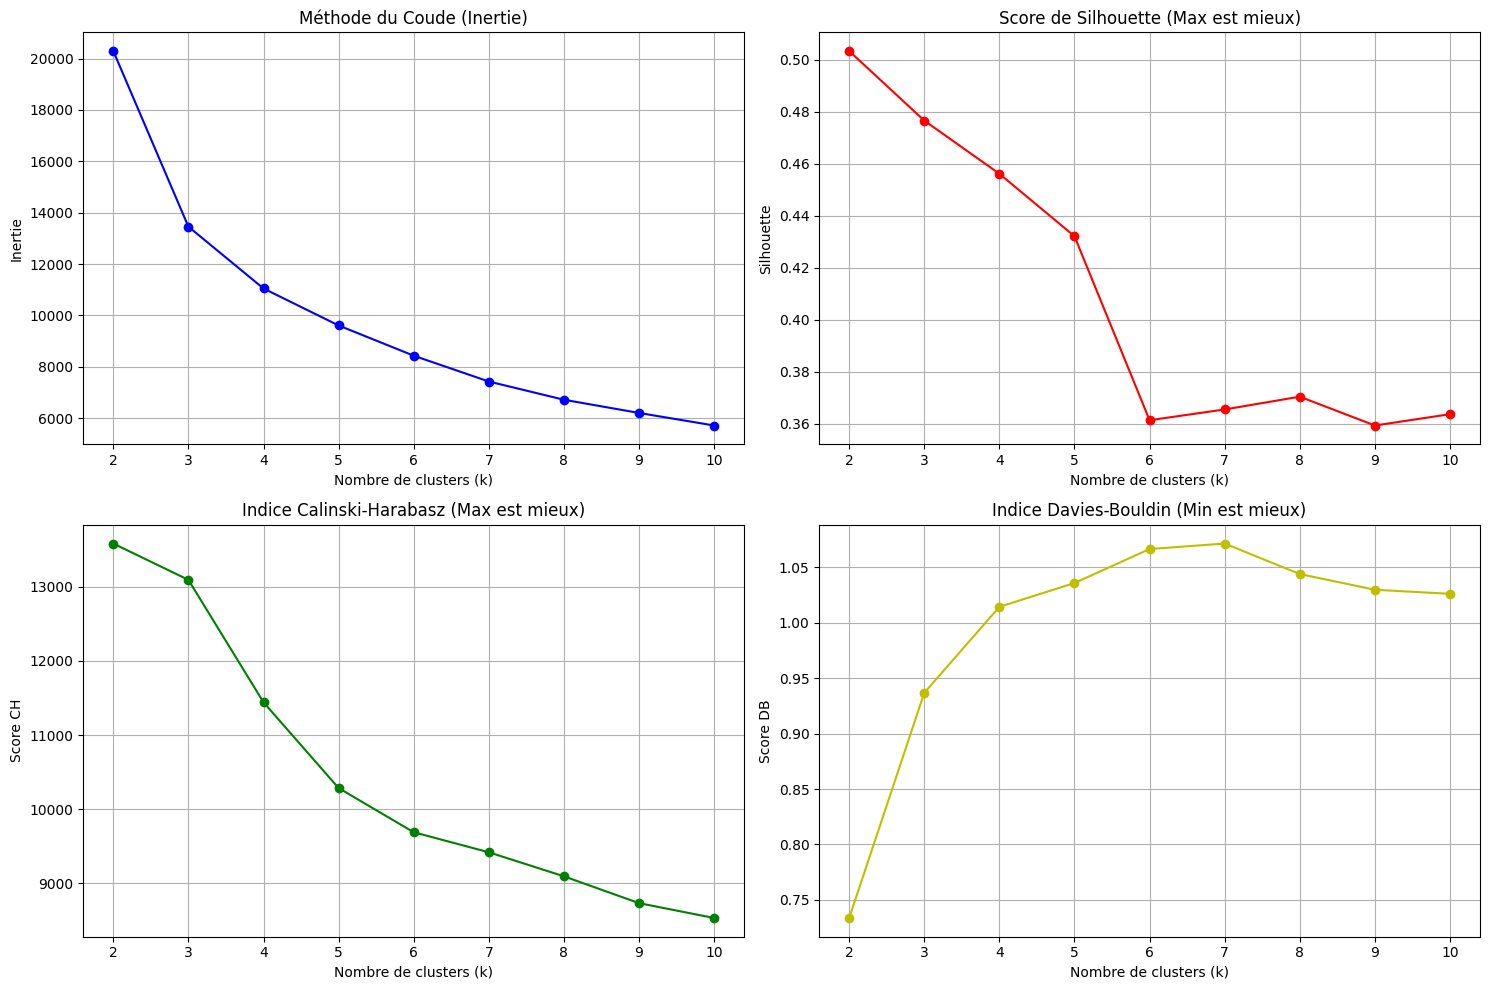

   Algo      Paramètres  n_clusters  Silhouette  Calinski-Harabasz  Davies-Bouldin  Bruit (outliers)
K-Means             k=2           2    0.503308       13579.750610        0.733669                 0
K-Means             k=3           3    0.476557       13090.375076        0.936822                 0
K-Means             k=4           4    0.456102       11440.818709        1.014340                 0
K-Means             k=5           5    0.432073       10285.261663        1.035846                 0
 DBSCAN eps=0.5, min=10           7    0.385404        3021.556357        2.015551               217
 DBSCAN eps=0.4, min=10           7    0.384951        2963.993601        2.181974               285
 DBSCAN  eps=0.5, min=5          11    0.370519        1989.014386        1.673500               136
K-Means             k=8           8    0.370341        9096.078074        1.043952                 0
K-Means             k=7           7    0.365430        9419.935789        1.071447         

,Algo,Paramètres,n_clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin,Bruit (outliers)
0,K-Means,k=2,2,0.503308,13579.750610,0.733669,0
1,K-Means,k=3,3,0.476557,13090.375076,0.936822,0
2,K-Means,k=4,4,0.456102,11440.818709,1.014340,0
3,K-Means,k=5,5,0.432073,10285.261663,1.035846,0
14,DBSCAN,"eps=0.5, min=10",7,0.385404,3021.556357,2.015551,217
12,DBSCAN,"eps=0.4, min=10",7,0.384951,2963.993601,2.181974,285
13,DBSCAN,"eps=0.5, min=5",11,0.370519,1989.014386,1.673500,136
6,K-Means,k=8,8,0.370341,9096.078074,1.043952,0
5,K-Means,k=7,7,0.365430,9419.935789,1.071447,0
8,K-Means,k=10,10,0.363604,8534.293462,1.026108,0


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def analyse_comparative_dbscan_kmeans(X):
    results = []

    # K-MEANS
    k_range = range(2, 11)
    metrics_km = {
        "inertia": [],
        "silhouette": [],
        "calinski": [],
        "davies": []
    }

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=1, n_init=10)
        labels = km.fit_predict(X)

        # Calcul des scores
        sil = silhouette_score(X, labels)
        cal = calinski_harabasz_score(X, labels)
        dav = davies_bouldin_score(X, labels)

        metrics_km["inertia"].append(km.inertia_)
        metrics_km["silhouette"].append(sil)
        metrics_km["calinski"].append(cal)
        metrics_km["davies"].append(dav)

        results.append({
            "Algo": "K-Means",
            "Paramètres": f"k={k}",
            "n_clusters": k,
            "Silhouette": sil,
            "Calinski-Harabasz": cal,
            "Davies-Bouldin": dav,
            "Bruit (outliers)": 0
        })

    # Visualisation K-MEANS
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Coude (Inertie)
    axes[0, 0].plot(k_range, metrics_km["inertia"], 'bo-')
    axes[0, 0].set_title('Méthode du Coude (Inertie)')
    axes[0, 0].set_ylabel('Inertie')

    # Silhouette
    axes[0, 1].plot(k_range, metrics_km["silhouette"], 'ro-')
    axes[0, 1].set_title('Score de Silhouette (Max est mieux)')
    axes[0, 1].set_ylabel('Silhouette')

    # Calinski-Harabasz
    axes[1, 0].plot(k_range, metrics_km["calinski"], 'go-')
    axes[1, 0].set_title('Indice Calinski-Harabasz (Max est mieux)')
    axes[1, 0].set_ylabel('Score CH')

    # Davies-Bouldin
    axes[1, 1].plot(k_range, metrics_km["davies"], 'yo-')
    axes[1, 1].set_title('Indice Davies-Bouldin (Min est mieux)')
    axes[1, 1].set_ylabel('Score DB')

    for ax in axes.flat:
        ax.set_xlabel('Nombre de clusters (k)')
        ax.grid(True)

    plt.tight_layout()
    plt.savefig("metriques_evaluation_kmeans.png")
    plt.show()

    # DBSCAN
    eps_values = [0.3, 0.4, 0.5]
    min_samples_values = [5, 10]

    for eps in eps_values:
        for ms in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=ms)
            labels = db.fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            # On ne calcule les scores que si au moins 2 clusters existent (hors bruit)
            if n_clusters > 1:
                results.append({
                    "Algo": "DBSCAN",
                    "Paramètres": f"eps={eps}, min={ms}",
                    "n_clusters": n_clusters,
                    "Silhouette": silhouette_score(X, labels),
                    "Calinski-Harabasz": calinski_harabasz_score(X, labels),
                    "Davies-Bouldin": davies_bouldin_score(X, labels),
                    "Bruit (outliers)": list(labels).count(-1)
                })

    df_res = pd.DataFrame(results)

    # Tri par Silhouette
    df_res = df_res.sort_values(by="Silhouette", ascending=False)

    print(df_res.to_string(index=False))

    return df_res

analyse_comparative_dbscan_kmeans(X_scaled)

In [40]:
import plotly.express as px

def generer_carte(k_choisi):
    kmeans = KMeans(n_clusters=k_choisi, random_state=1, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    df_prepare['cluster_id'] = clusters

    # Tri logique : on force l'ID 0 à être le plus petit en hauteur moyenne
    ordre = df_prepare.groupby('cluster_id')['haut_tot'].mean().sort_values().index
    mapping_tri = {old: str(new) for new, old in enumerate(ordre)}
    df_prepare['Categorie_ID'] = df_prepare['cluster_id'].map(mapping_tri)

    # Libellés selon le choix utilisateur
    noms_dynamiques = {i: f"Groupe {i}" for i in range(k_choisi)}

    if k_choisi == 2:
        noms_dynamiques = {0: "Petit", 1: "Grand"}
    elif k_choisi == 3:
        noms_dynamiques = {0: "Petit", 1: "Moyen", 2: "Grand"}

    df_prepare['Nom_Categorie'] = df_prepare['Categorie_ID'].astype(int).map(noms_dynamiques)

    liste_ordonnee = [noms_dynamiques[i] for i in range(k_choisi)]

    fig = px.scatter_map(
        df_prepare,
        lat="lat", lon="long",
        color="Nom_Categorie",
        size="haut_tot",
        hover_data=['haut_tot', 'fk_stadedev', 'age_estim', 'tronc_diam'],
        category_orders={"Nom_Categorie": liste_ordonnee},
        map_style="open-street-map",
        zoom=12, height=600
    )
    fig.show()

try:
    nb = int(input("Nombre de catégories pour la carte ? (2 et 3 auto-générés) : "))
    generer_carte(2)
    generer_carte(3)
except:
    print("Entrée invalide.")
    generer_carte(2)
    generer_carte(3)

Nombre de catégories pour la carte ? (2 et 3 auto-générés) : 
Entrée invalide.


In [41]:
import joblib
from sklearn.cluster import KMeans

try:
    K_FINAL = int(input("Entrez le nombre final de catégories pour l'export (recommandé : 2) : "))
except ValueError:
    print("Entrée invalide, utilisation de la valeur par défaut : 2")
    K_FINAL = 2

model_final = KMeans(n_clusters=K_FINAL, random_state=1, n_init=10)
clusters = model_final.fit_predict(X_scaled)

# Calcul des moyennes pour le mapping
df_tri = pd.DataFrame({'cluster_id': clusters, 'hauteur_m': df_prepare['haut_tot']})
moyennes = df_tri.groupby('cluster_id')['hauteur_m'].mean().sort_values()

ordre_ids = moyennes.index

# Gestion dynamique des noms
if len(ordre_ids) == 3:
    noms_labels = ["Petit", "Moyen", "Grand"]
elif len(ordre_ids) == 2:
    noms_labels = ["Petit", "Grand"]
else:
    # Pour k > 3, on génère des étiquettes numériques ou textuelles automatiques
    noms_labels = [f"Taille {i}" for i in range(len(ordre_ids))]

# Création du mapping sécurisé
mapping_noms = {int(cluster_id): noms_labels[i] for i, cluster_id in enumerate(ordre_ids)}
print(moyennes)

# Sauvegarde
joblib.dump(model_final, 'modele_arbres.pkl')
joblib.dump(scaler, 'scaler_arbres.pkl')
joblib.dump(mapping_noms, 'mapping_noms.pkl')

Entrez le nombre final de catégories pour l'export (recommandé : 2 ou 3) : 2
cluster_id
1     6.582438
0    13.665584
Name: hauteur_m, dtype: float64


['mapping_noms.pkl']

In [ ]:
import joblib
import pandas as pd

def diagnostic_arbre():
    model = joblib.load('modele_arbres.pkl')
    scaler = joblib.load('scaler_arbres.pkl')
    mapping = joblib.load('mapping_noms.pkl')

    print(f"Diagnostic : ({len(mapping)} catégories)")
    hauteur_totale = float(input("Hauteur totale en MÈTRES (ex: 15) : "))

    stade_table = """
      Table de correspondance :
      1 -> "Jeune"
      2 -> "Adulte"
      3 -> "Vieux/Sénescent"
    """
    print(stade_table)
    fk_stadedev = int(input("Entrez le chiffre correspondant au stade : "))
    age_estim = int(input("Age de l'arbre : "))
    diametre_tronc = float(input("Diamètre souhaité en CM (ex: 100) : "))

    entree = pd.DataFrame([[hauteur_totale, fk_stadedev, age_estim, diametre_tronc]], columns=['haut_tot', 'fk_stadedev', 'age_estim', 'tronc_diam'])
    scaled = scaler.transform(entree)

    res_id = int(model.predict(scaled)[0])
    nom_final = mapping.get(res_id, "Inconnu")

    print(f"\nCet arbre est classé : {nom_final}")

diagnostic_arbre()

Diagnostic : (2 catégories)
Hauteur totale en MÈTRES (ex: 15) : 10

      Table de correspondance :
      1 -> "Jeune"
      2 -> "Adulte"
      3 -> "Vieux/Sénescent"
    
Entrez le chiffre correspondant au stade : 3
Age de l'arbre : 5
Diamètre souhaité en CM (ex: 100) : 80

Cet arbre est classé : Grand
